# Intro to pandas

In this notebook we introduce **pandas**, a Python library for working with **tabular data** (tables of rows and columns), which shows up constantly in experimental and computational physics:

- Time series (e.g. detector counts vs time)
- Experimental runs (temperature, pressure, voltage, current,
  etc.)
- Simulation outputs (parameter scans, Monte Carlo samples)

We will cover:

1. What is a **Series** and a **DataFrame**?
2. Creating DataFrames from Python and NumPy.
3. **Reading and writing CSV files** with `pandas.read_csv` and `DataFrame.to_csv`.
4. Selecting and filtering data: columns, rows, conditions.
5. Handling **missing data**.
6. Simple **grouping and statistics** (`groupby`).
7. Quick **plotting** from a DataFrame.


The **official documentation** for pandas lives at `https://pandas.pydata.org/docs/`. Of course, secondary sources like `google` and `chatgpt` can be helpful (or not).

In [ ]:
!python3 --version

## 1. Imports and basic setup

Import **NumPy**, **pandas**, and **matplotlib**. Pandas is conventionally imported as `pd`.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit nicer
%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

pd.__version__     # Tells us what version  pandas you are using. Note the double underscores on either side of version

'2.3.3'

## 2. Series and DataFrames

The two main data structures in pandas are:

- **Series**: a 1D labeled array (like a column in a table).
- **DataFrame**: a 2D table of **rows and columns**, where each column is a Series.

For the sophisticate: You can think of a DataFrame as a **dict of Series** with a common index (row labels).   
If you do not know what a dictionary (dict) is, don't worry about it.

### 2.1 A simple Series

We create a Series from a Python list or a NumPy array. Pandas automatically gives it an **index** (row labels).

In [ ]:
temps = pd.Series([20.1, 21.3, 19.8, 22.0], name="temperature_C")  # Note the capital "S"
temps

- The left column is the **index** (0, 1, 2, 3).
- The right column is the **data**.
- The `name` is an optional label for the Series.

You access values just like a NumPy array or list:

In [5]:
print("First element:", temps[0])
print("As NumPy array:", temps.to_numpy())
print("Mean temperature:", temps.mean())       # Note that mean() acts on the entire array.

First element: 20.1
As NumPy array: [20.1 21.3 19.8 22. ]
Mean temperature: 20.8


### 2.2 A simple DataFrame

A **DataFrame** can be built from a dictionary of lists/arrays. The **keys** become column names; the values are the column data.   
A python **dictionary** is a data structure with keys (think words) and **values** (think word defintion). A given key can only have   
one value, unlike an actual word dictionary.

In the example below, pay attention to the syntax for the dictionary named "data": the encompassing braces {}. they key:value structure, and the key-value pairs separated by commas.

You are buildng a "data frame," a table of values with column headers. 'df" stands for data frame. common usage.

In [ ]:
data = {
    "time_s": [0, 1, 2, 3],
    "voltage_V": [1.0, 0.9, 0.8, 0.7],
    "current_mA": [10.0, 9.8, 9.6, 9.5],
}

df = pd.DataFrame(data)
df

Each **column** behaves like a Series with a shared index:

- `df["time_s"]` is a Series.
- `df["voltage_V"]` is another Series.

You access them like this:

In [ ]:
df["voltage_V"]
print(df.columns.tolist())
# or equivalently (if the column name is a valid Python identifier):
df.voltage_V

You can also create a DataFrame directly from NumPy arrays. This is common in computational physics when you simulate arrays of values and then want to analyze them with pandas.

In [ ]:
N = 5
t = np.linspace(0, 4, N)
x = np.sin(t)
v = np.cos(t)

df2 = pd.DataFrame({"t": t, "x": x, "v": v})
df2

Useful methods to get a quick feel for a DataFrame:

- `df.head()` – first few rows
- `df.info()` – column types and non-missing counts
- `df.describe()` – summary statistics for numeric columns

In [ ]:
df2.head()

In [ ]:
df2.info()

In [ ]:
df2.describe()

## 3. Example physics dataset: radioactive decay measurements

Let’s create a **simulated physics dataset** to demonstrate pandas. Imagine an experiment measuring the count rate from a radioactive source over time.

- True model: $N(t) = N_0 e^{-t/\tau}$
- We measure counts in equal time bins.
- We add some Poisson noise to make it look realistic.

We will store the data in a DataFrame with columns:

- `time_s` – time in seconds
- `counts` – measured counts in this time bin
- `rate_Hz` – counts per second (just `counts / bin_width`) (we’ll compute this with pandas).

In [ ]:
rng = np.random.default_rng(123)

N0_true = 500.0      # initial expected counts per bin
tau_true = 4.0       # characteristic decay time in seconds
bin_width = 0.5      # seconds
n_bins = 50

time_s = np.arange(n_bins) * bin_width
expected_counts = N0_true * np.exp(-time_s / tau_true)

# Add Poisson statistical fluctuations around the expected counts
counts = rng.poisson(expected_counts)

decay_df = pd.DataFrame({
    "time_s": time_s,
    "counts": counts
})

decay_df.head()

We can add new columns simply by assigning to them. For example, we can compute the **measured rate** (counts per second) and an estimated **uncertainty** on the counts (we sensibly assume Poisson statistics, $\sigma \approx \sqrt{N}$ for counts):

In [ ]:
decay_df["rate_Hz"] = decay_df["counts"] / bin_width
decay_df["sigma_counts"] = np.sqrt(decay_df["counts"])
decay_df.head()

## 4. Reading and writing CSV files with pandas

CSV (**Comma-Separated Values**) files are a very common way to store tabular data.

With pandas:

- `DataFrame.to_csv("filename.csv", index=False)` – write a DataFrame to a CSV file.
- `pd.read_csv("filename.csv")` – read a CSV file into a DataFrame.

We’ll demonstrate this by **writing our decay data to a CSV file** and then reading it back.

In [5]:
csv_filename = "decay_data.csv"

# Write decay_df to CSV (no row index column)
decay_df.to_csv(csv_filename, index=False)

print("Wrote:", csv_filename)

Wrote: decay_data.csv


In [ ]:
# Read the CSV back into a new DataFrame
decay_from_file = pd.read_csv(csv_filename)
decay_from_file.head()

Notice that the DataFrame we read from the file has the same columns as before.

**Important options for `read_csv`:**

- `sep=","` – delimiter (default is comma, but you can use e.g. `sep="\t"` for tab-separated).
- `header=0` – which row contains column names (0 = first row).
- `comment="#"` – lines starting with `#` are ignored (useful if your data files have commented headers).
- `na_values=[...]` – which strings are interpreted as missing values.

Example (not run here):
```python
data = pd.read_csv("my_data.txt", sep="\t", comment="#")
```

## 5. Selecting and filtering data

Pandas gives several ways to select parts of your DataFrame:

- By **columns**: `df["col"]`, `df[["col1", "col2"]]`
- By **row index**: `df.iloc[...]` (integer-based), `df.loc[...]` (label-based)
- By **boolean masks** (conditions): `df[df["counts"] > 100]`

We’ll illustrate these with our decay data.

### 5.1 Selecting columns

Get one column (a Series):

In [ ]:
decay_df["counts"].head()

Get multiple columns (still a DataFrame):

In [ ]:
decay_df[["time_s", "counts"]].head()

### 5.2 Selecting rows with `iloc` and `loc`

- `iloc` uses **integer positions** (0, 1, 2, ...).
- `loc` uses **labels** from the index (in this case the default index is 0, 1, 2, ... so it looks similar, but in more advanced use you can label rows by time, run ID, etc.).

In [ ]:
# First 5 rows (like slices)
decay_df.iloc[0:5]

In [ ]:
# Row with index 10
decay_df.iloc[10]

Selecting a **block** of rows and columns:

- `iloc[row_slice, column_slice]`.

In [ ]:
# Rows 0..4, columns 0..2
decay_df.iloc[0:5, 0:3]

### 5.3 Boolean indexing (conditions)

This is extremely useful in data analysis: you keep only rows that satisfy some condition.

Example: select only rows where `counts > 200`:

In [ ]:
high_counts = decay_df[decay_df["counts"] > 200]
high_counts

We can also combine conditions:

- Use `&` for **and**, `|` for **or**.
- Remember to use parentheses around each comparison.

Example: **select times between 5 and 15 seconds** where counts are above 100:

In [ ]:
mask = (
    (decay_df["time_s"] >= 5) &
    (decay_df["time_s"] <= 15) &
    (decay_df["counts"] > 100)
)
decay_df[mask]

## 6. Handling missing data

Real physics data often has **missing values** (e.g. detector glitches, bad channels, incomplete logs). Pandas uses `NaN` (Not a Number) to represent missing values.

Key functions:

- `df.isna()` – True where values are missing.
- `df.dropna()` – remove rows with missing values.
- `df.fillna(value)` – replace missing values with a specified value.

We’ll make a tiny example DataFrame with some missing entries to see how this works.

In [ ]:
demo = pd.DataFrame({
    "time_s": [0, 1, 2, 3, 4],
    "voltage_V": [1.0, np.nan, 0.9, np.nan, 0.7]
})
demo

`NaN` shows up where the data is missing. Use `isna()` to see a boolean mask:

demo.isna()

Drop rows with any missing values using `dropna()`:

In [ ]:
demo_drop = demo.dropna()
demo_drop

Alternatively, **fill** missing values with something, e.g. **interpolate** or use a constant (maybe the mean or last valid value). Here we’ll fill with the **mean voltage** of the non-missing entries.

mean_voltage = demo["voltage_V"].mean()  # ignores NaN by default
demo_filled = demo.copy()
demo_filled["voltage_V"] = demo_filled["voltage_V"].fillna(mean_voltage)
demo_filled

## 7. Grouping and basic statistics (`groupby`)

In experiments, we often have **multiple runs** or **detectors**, and we want to compute statistics for each group separately.

We’ll create a **fake dataset** where we have decay measurements from **two different detectors** (A and B). Each detector measures counts vs time. We’ll then use `groupby` to compute mean and standard deviation per detector and per time bin.

In [ ]:
rng = np.random.default_rng(321)

detectors = ["A", "B"]
n_bins = 20
time_s = np.arange(n_bins)

rows = []
for det in detectors:
    # Slightly different N0 for each detector
    N0_det = 400.0 if det == "A" else 450.0
    tau_det = 10.0
    expected_counts = N0_det * np.exp(-time_s / tau_det)
    counts_det = rng.poisson(expected_counts)
    for t, c in zip(time_s, counts_det):
        rows.append({"detector": det, "time_s": t, "counts": c})

multi_df = pd.DataFrame(rows)
multi_df.head(10)

We can compute the **mean counts per detector** like this:

In [28]:
multi_df.groupby("detector")["counts"].mean()

detector
A    185.05
B    205.15
Name: counts, dtype: float64

We can also group by **both** detector and time, and compute statistics per time bin for each detector (though here we have just one row per time per detector):

In [ ]:
multi_df.groupby(["detector", "time_s"])["counts"].agg(["mean", "std"]).head(10)

This `groupby` pattern is extremely common:

- Group by **run ID**, **detector**, **magnetic field setting**, etc.
- Aggregate with `.mean()`, `.std()`, `.sum()`, `.count()`, etc.

It’s a powerful way to summarize large experimental datasets.

## 8. Quick plotting with pandas

Pandas integrates with matplotlib to allow quick plots:

- `df.plot(x="time_s", y="counts")`
- `df["counts"].plot()` for 1D plots.

We’ll plot our original `decay_df` data and compare it to the underlying true exponential curve (without noise).

In [ ]:
decay_df.head()

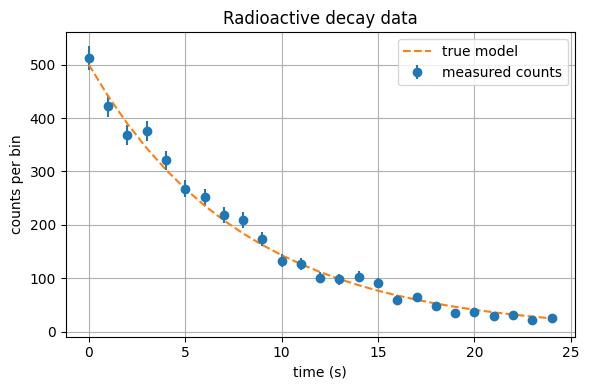

In [31]:
# Recompute true expected counts for plotting
expected_counts = N0_true * np.exp(-decay_df["time_s"] / tau_true)

plt.figure()
plt.errorbar(
    decay_df["time_s"],
    decay_df["counts"],
    yerr=decay_df["sigma_counts"],
    fmt="o",
    label="measured counts",
)
plt.plot(decay_df["time_s"], expected_counts, label="true model", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("counts per bin")
plt.title("Radioactive decay data")
plt.legend()
plt.tight_layout()
plt.show()

We can also use **pandas' built-in plot** method, which is a thin wrapper around matplotlib. For quick checks it’s handy:

```python
decay_df.plot(x="time_s", y="counts", yerr="sigma_counts", fmt="o")
```

but for more control, using matplotlib directly (as above) is usually better in a physics context.

## 9. Summary

Key points:

1. **Series** and **DataFrames** are the core data structures.
2. You can easily build DataFrames from Python lists/dicts or NumPy arrays.
3. `read_csv` and `to_csv` make it easy to move between Python and text-based data files.
4. Selection and filtering (`df["col"]`, `df.iloc`, `df.loc`, boolean masks) are crucial for data cleanup.
5. Handling missing data (`isna`, `dropna`, `fillna`) is essential in real experiments.
6. `groupby` lets you compute statistics per detector, per run, per time bin, etc.
7. Pandas integrates nicely with matplotlib for quick plotting.

Pandas is commonly used when working with **real experimental data**: multiple runs, many columns, and large files.

---

### Exercises (to be continued)

1. **Modify the decay example**: change the bin width or $N_0$ and regenerate data; recompute `rate_Hz` and replot.
2. Create a **CSV file** of your own simulated experiment (e.g. position vs time for a falling object), read it with `pandas`, and compute derived quantities (velocity, acceleration).
3. Add a `"run"` column to the decay dataset (e.g. 3 different runs with slightly different $N_0$) and use `groupby("run")` to compute mean and standard deviation of counts per run.
4. Explore `pandas.plot()` for quick visualization and compare with manual matplotlib plotting.
5. Load a **real physics dataset** (sunspot numbers, atmospheric CO$_2$, etc.) from a CSV file and practice filtering, grouping (by year), and plotting.



6. Read into a dataframe the file `sunspots.txt`. Call the dataframe something sensible.
   Use the `head()` function to examine it. What is that weird set of characters at the very top?
   The weird set says there is only 1 column for both numbers and `\t` tells you the numbers are separated by a tab.
   This isn't what we want. We want 2 separate columns. So, execute `pd.read_csv(csv_filename, sep="\t", header=None)`.
   Here the csv_filename is the csv-like file you want to read, numbers separated by a tab, and no headers.
   Examine your data frame using the `head()` and `info()` functions. What do you see?

   With no headers, the columns are labeled by integers. This makes it hard to know what the column numbers mean. The solution is to
   change the column names to something meaningful. How? Pick sensible names for your columns and execute:
   
   `df.columns = ['column1 name', 'column2 name']`  (Here, `df` represents the actual name of **your** dataframe.)

   Use `head()` and `info()` to examine the dataframe. Again. What do you see? Hopefully, much better.

   **Plot** your data using the pandas quick plotting technique demonstrated above. What do you see?
   Compare this plot with the one you get from using the matplotlib technique. Are they identical?
   

Can rename columns to something easier to understand: `sunspots_from_file.columns["month", "Number of sunspots"]`

In [28]:
sunspots_from_file.columns = ['month','Number of sunspots']

sunspots_from_file.head()

In [ ]:
plt.plot(sunspots_from_file["month"], sunspots_from_file["Number of sunspots"])

sunspots_from_file.plot(x="month", y="Number of sunspots")

7. Read the file `solar_irradiance_seasonal.csv` into a dataframe. Use `head()` and `info` to examine it.
   **Plot** the irradiance as a function  of time for all the available times.
   Now, **plot** separate years, one plot per year. (You will need to undertsand filtering. See above.) Do they look the same by eye?

Read the file `light_curve_cepheid_simulated.csv` into a data frame. Examine it. **Plot** the star count versus galactic latitude.   
    Wikipedia has a good figure to illustrate galactic latitude.

### Last Day

In [ ]:
import pandas as pd

# URL for Mauna Loa monthly mean CO2 (NOAA GML)
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

# Read the file, skipping header lines that start with '#'
df_raw = pd.read_csv(
    url,
    comment="#",
    sep='\s+',
    header=None,
    na_values=[-99.99, -1]
)

# According to NOAA's format, the columns are:
# 0: year
# 1: month
# 2: decimal date
# 3: monthly average CO2 (ppm)
# 4: deseasonalized trend (ppm)
# 5: # of days with data
# 6: standard deviation (days)
# 7: unc (uncertainty) (ppm)

df_raw.columns = [
    "year",
    "month",
    "decimal_date",
    "co2_ppm",
    "co2_deseasonalized_ppm",
    "n_days",
    "stdev_days",
    "unc_ppm",
]

# Drop rows where CO2 is missing
df = df_raw.dropna(subset=["co2_ppm"]).reset_index(drop=True)

# Save a clean CSV for students to use later
csv_filename = "mauna_loa_co2_monthly.csv"
df.to_csv(csv_filename, index=False)

print(f"Saved cleaned CO2 data to {csv_filename}")
df.head()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

co2 = pd.read_csv("mauna_loa_co2_monthly.csv")

plt.figure(figsize=(7,4))
plt.plot(co2["decimal_date"], co2["co2_ppm"])
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.title("Mauna Loa Atmospheric CO$_2$ (monthly mean)")
plt.grid(True)
plt.tight_layout()
plt.show()
